#### Case opti-4: Isobaric evaporation of ammonia in a large tank for long-term storage


In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Opti_jax

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Import JAX library
import jax
import jax.numpy as jnp

# Import time
import time

# Set JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)


#### Setup tank and cryogen properties

In [2]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K

V_tank = 165000 # Tank volume / m^3

#a   = 1
#d_i = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m
d_i = 76.4
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.038 # 0.08 # W/m2/K
U_V = 0.038 # 0.08 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.9

# Specify tank operating pressure
P = 100000 # Pa

# Set fixed bottom heat ingress
q_b_fixed = None # W/m2

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)
large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = q_b_fixed, Q_roof = 0, eta_w = 0.70)

# # Initialise cryogen
cryogen = Cryogen(name = "methane")
cryogen.set_coolprops(P)

# # Set cryogen
large_tank.cryogen = cryogen

# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))
# comparison of heat flux
print(d_i)
print("q_b used: ", q_b_fixed, " q_b free: ", U_L*(T_air - cryogen.T_sat))
print("Q_b used: ", large_tank.Q_b, " Q_b free: ", U_L*(T_air - cryogen.T_sat)*(np.pi*((d_i**2)/4)))
print("Q_l used: ", large_tank.Q_L_in, " q_l :", large_tank.Q_L_in/large_tank.A_L)

The initial evaporation rate of methane is 656.0 kg/h
76.4
q_b used:  None  q_b free:  7.092410212587223
Q_b used:  32514.003264856216  Q_b free:  32514.003264856216
Q_l used:  56245.41229846004  q_l : 7.0924102125872235


Calculate initial evaporation rate and transient period

In [3]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of methane is 656.0 kg/h
Transient period = 325010.242 s 
Simulation time: 91 h
BOR = 0.025 %


#### Simulation setup and execution

In [4]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 720 hours
evap_time = 3600 * 720

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
# large_tank.evaporate(evap_time)

In [5]:
opti = Opti_jax(large_tank)

+-------------------------------------------------------------+
| Optimal Thermal aspect ratio:    0.6676739615319031               |
| Optimal Geometric aspect ratio:  0.5176676676676677               |
| Minimal BOR:                     0.0002475126310589326               |
+-------------------------------------------------------------+


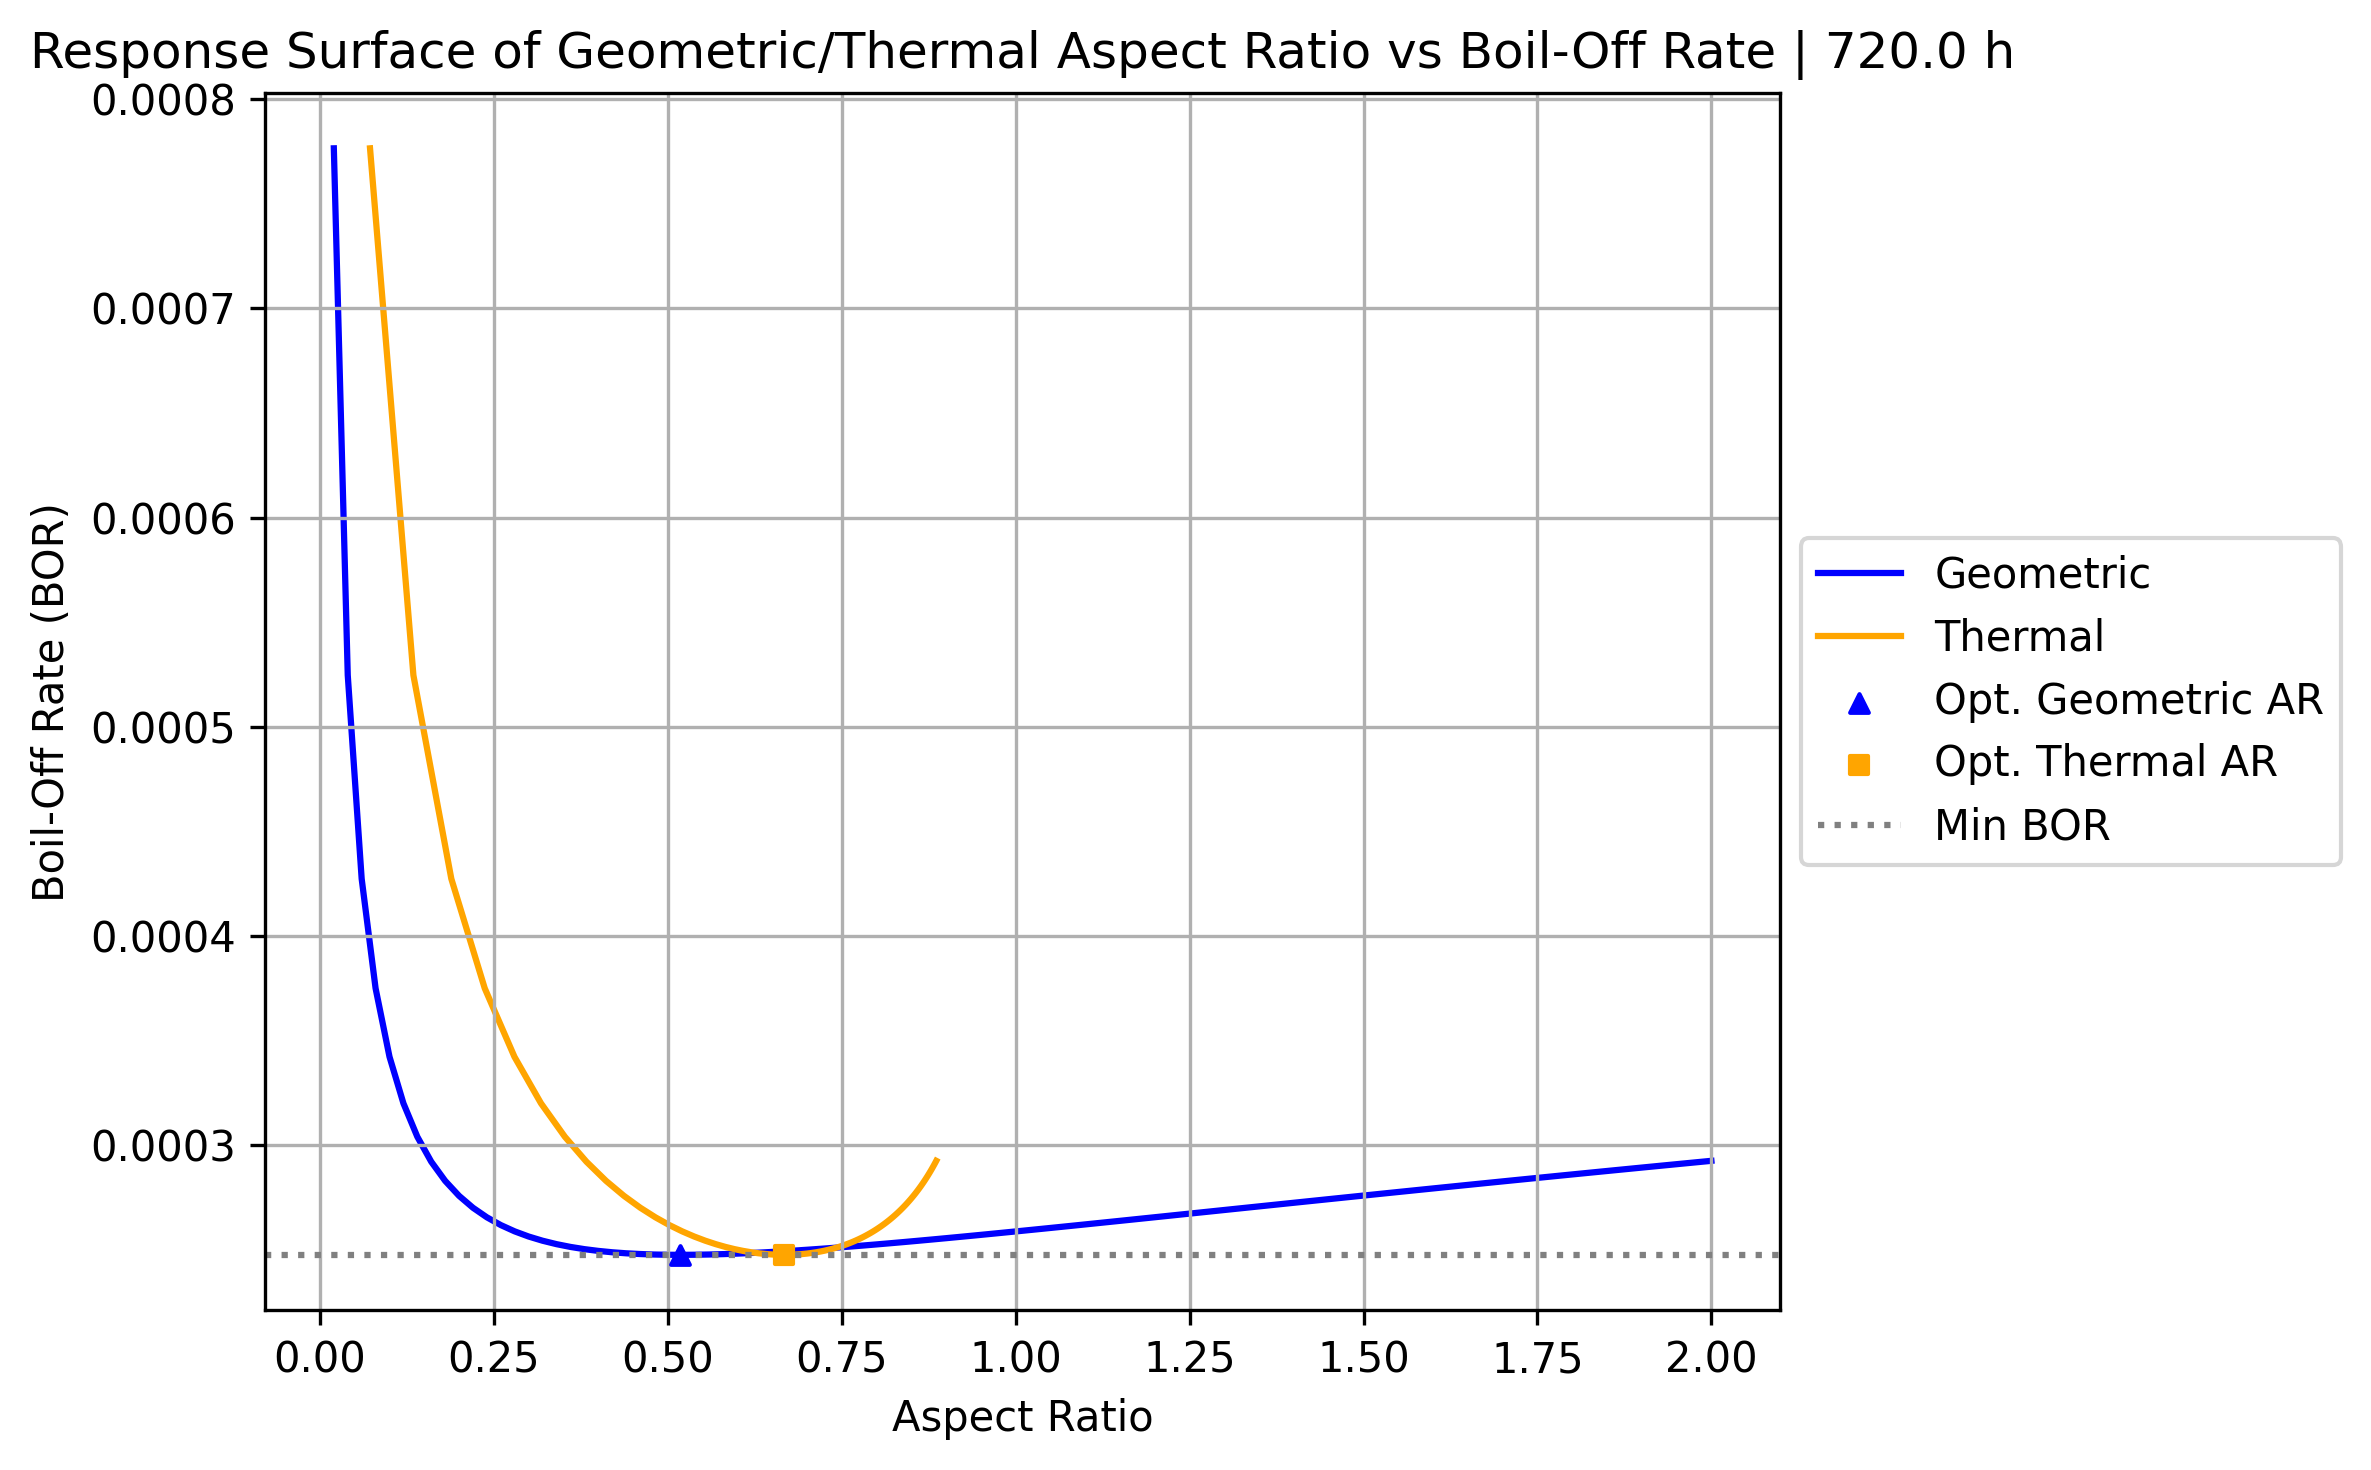

In [6]:
opti.plot_aspect_ratio_surface_response(jnp.linspace(0.02, 2, 100), 720*3600)

optimal Aspect Ratio: [0.93390208 0.78478023 0.68936664 0.62289107 0.57413322 0.53734189
 0.50905906]
optimal Thermal Aspect Ratio: [0.72765685 0.70470746 0.68948152 0.67932665 0.67277184 0.66897919
 0.66735762]
optimal BOR: [0.00333045 0.00089618 0.00054417 0.00040099 0.00032238 0.00027217
 0.000237  ]


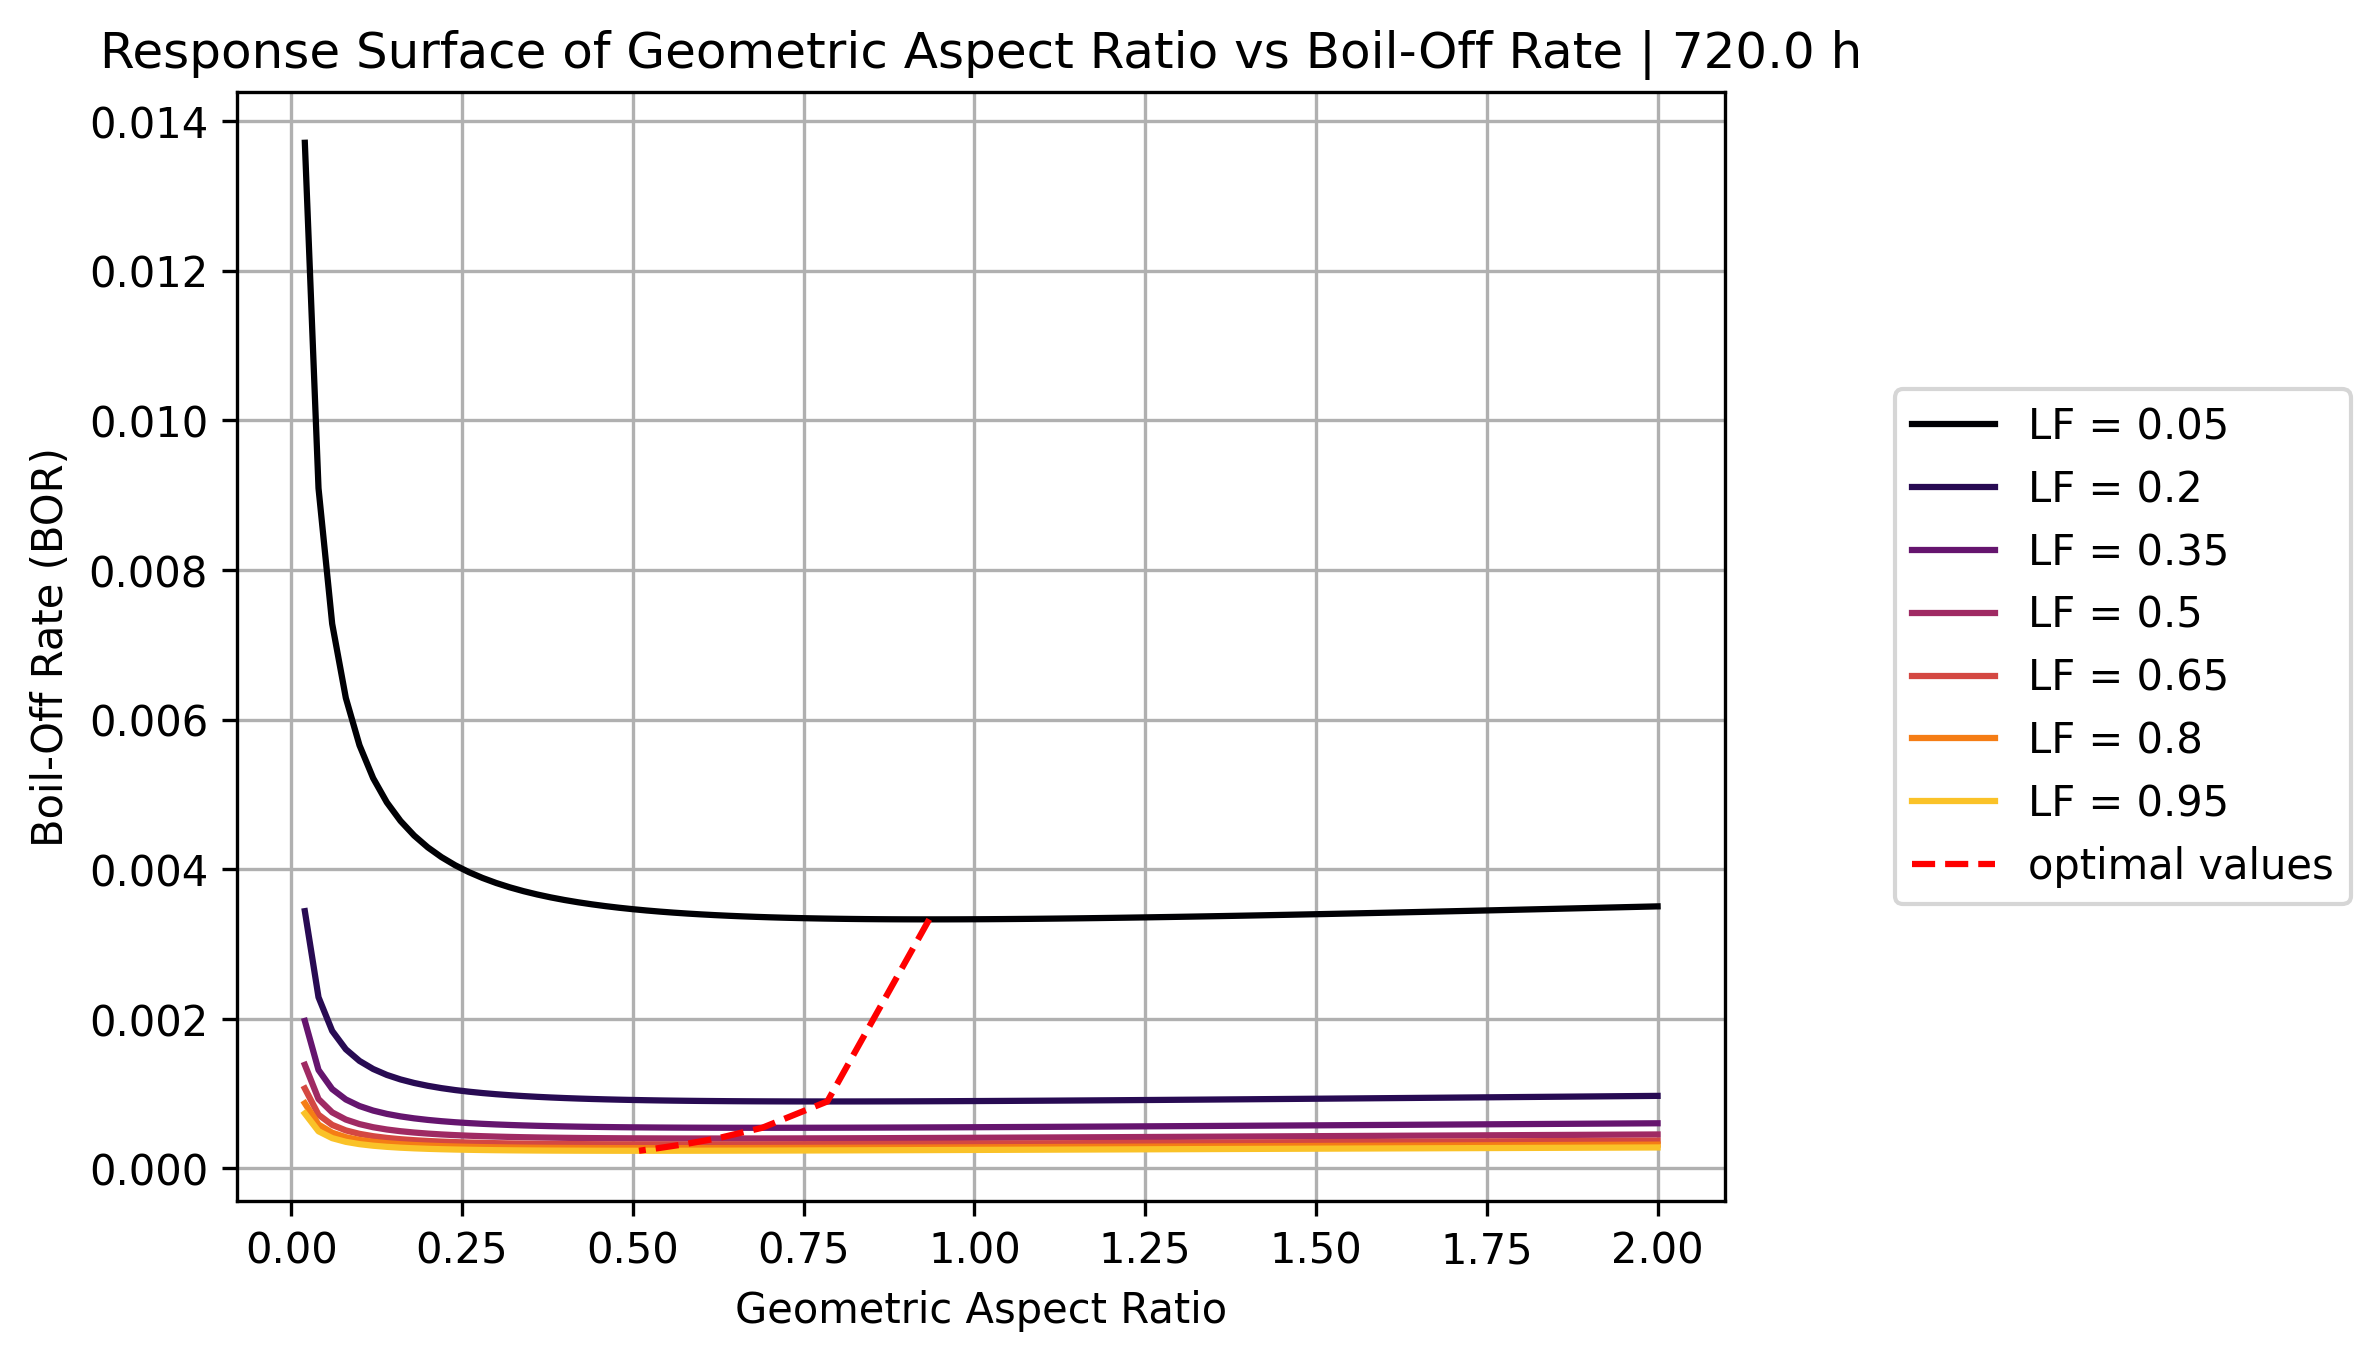

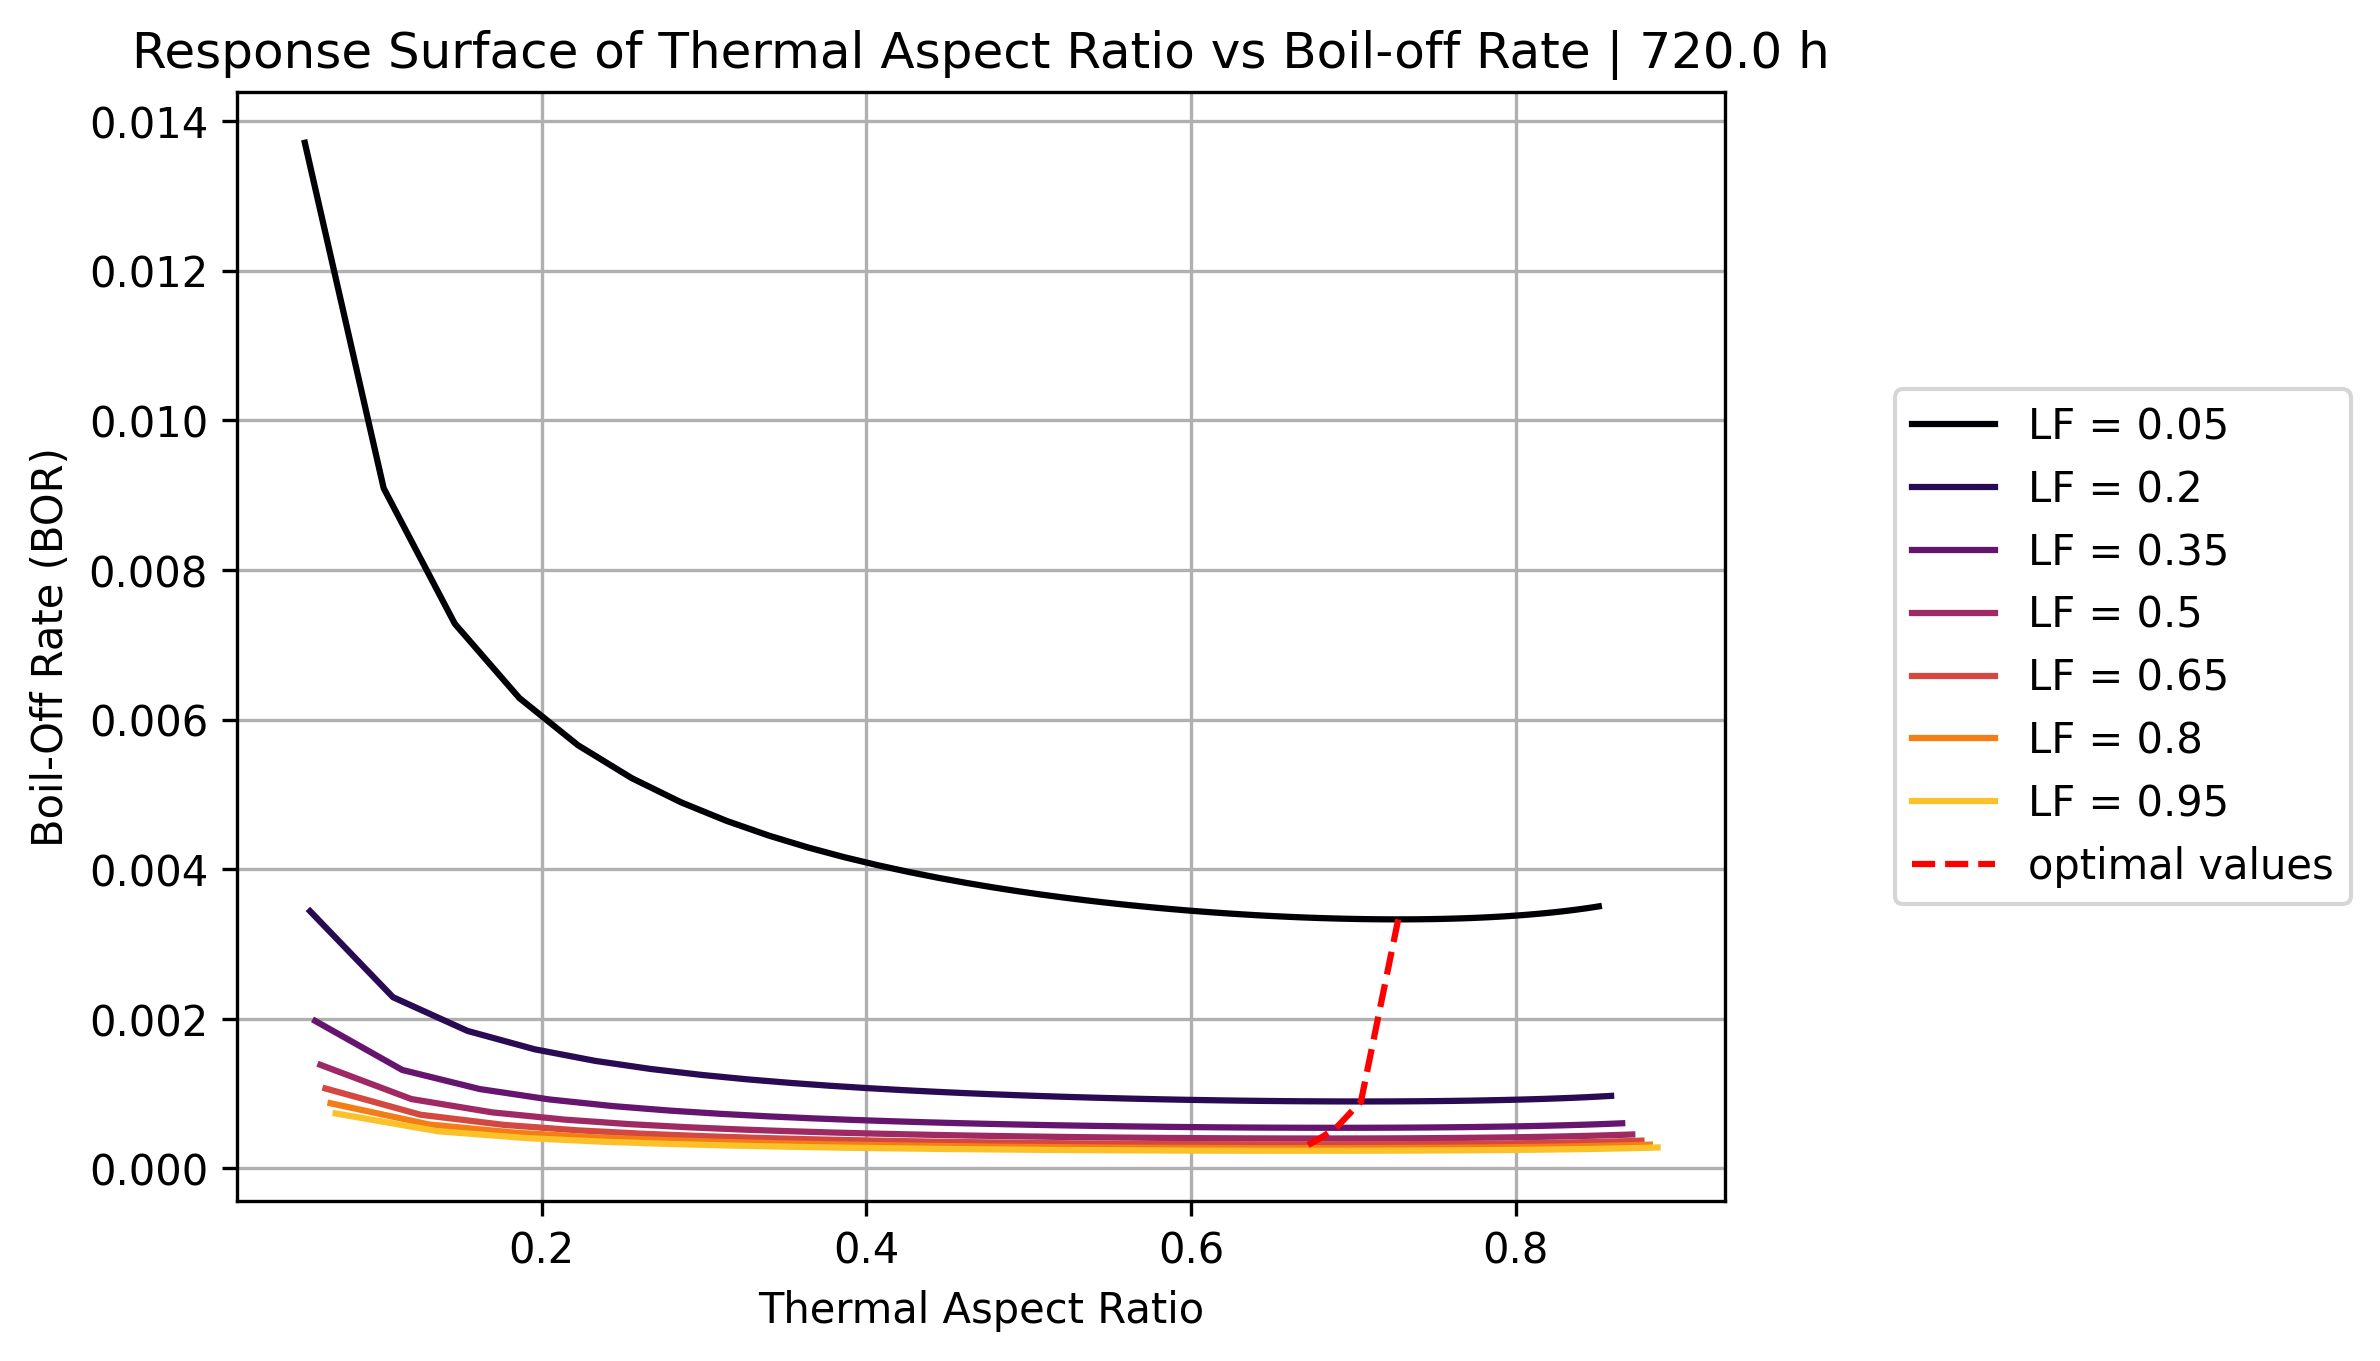

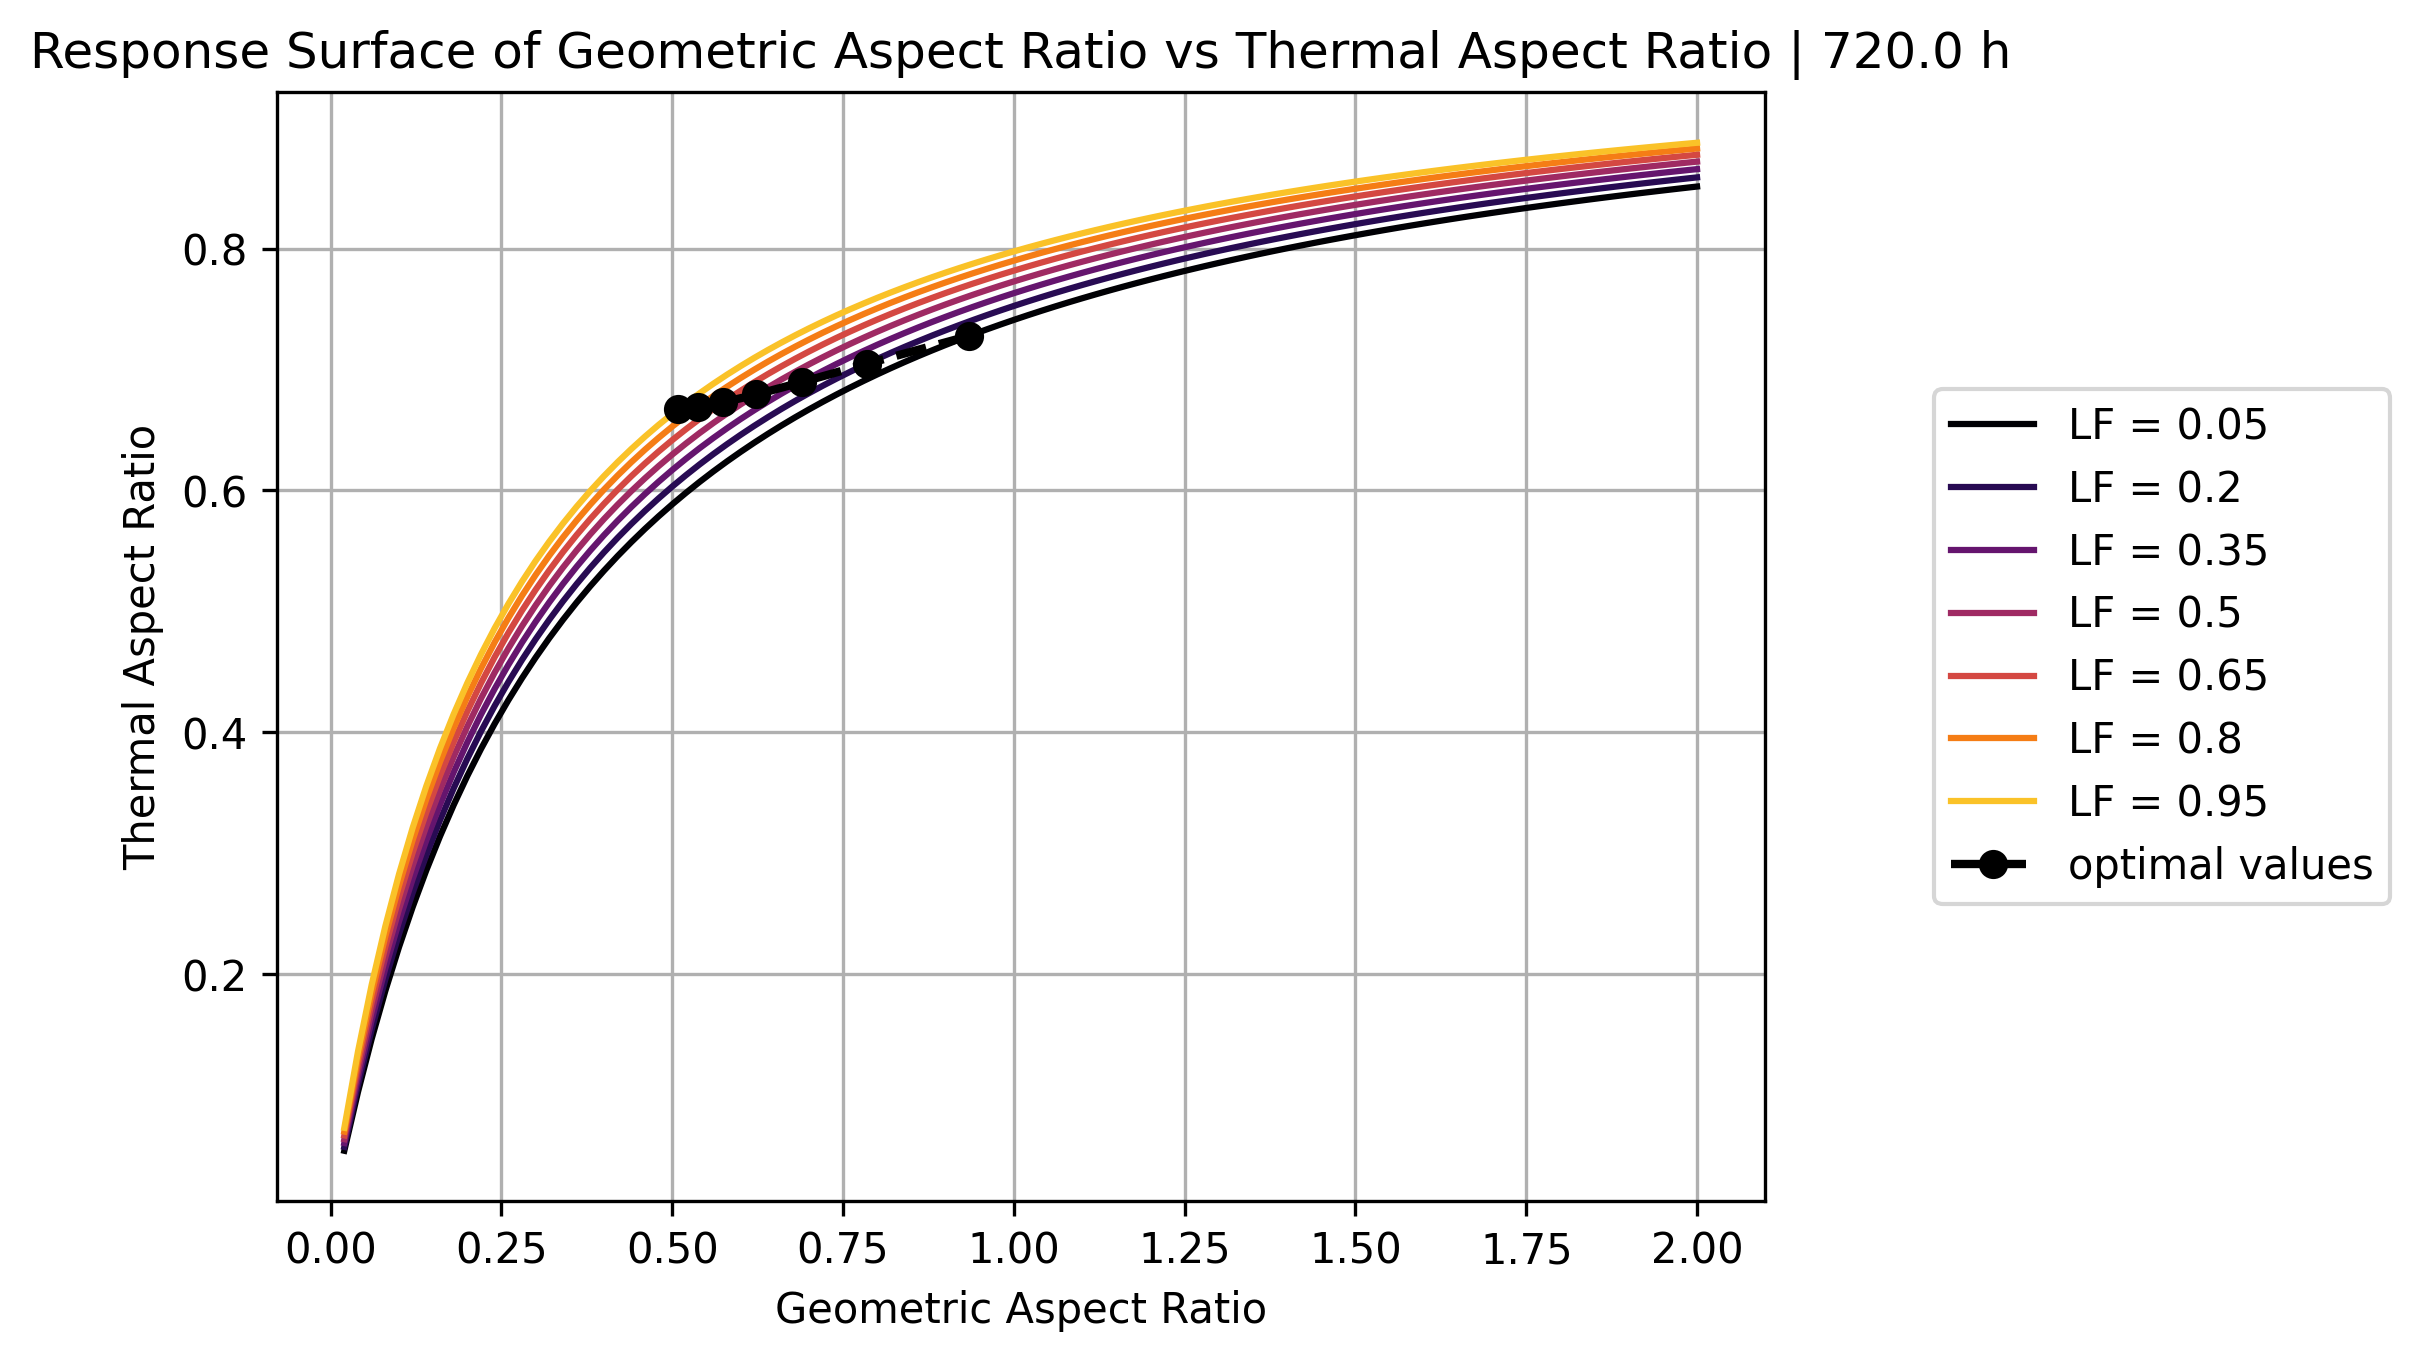

In [7]:
opti.plot_surface_response_thermal_aspect_ratio_liquid_filling(jnp.linspace(0.02, 2, 100), jnp.array([0.05,0.20,0.35,0.50,0.65,0.8,0.95]),720*3600)

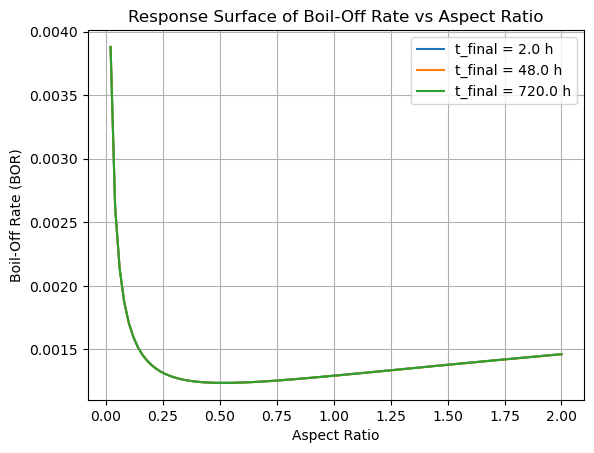

In [6]:
opti.plot_surface_response(jnp.linspace(0.02, 2, 100), 2*3600)
opti.plot_surface_response(jnp.linspace(0.02, 2, 100), 48*3600)
opti.plot_surface_response(jnp.linspace(0.02, 2, 100), 720*3600)

optimal Aspect Ratio: [0.93383838 0.72171717 0.61464646 0.55       0.50757576]
optimal BOR: [0.00835423 0.00298251 0.00192007 0.00145253 0.00118437]


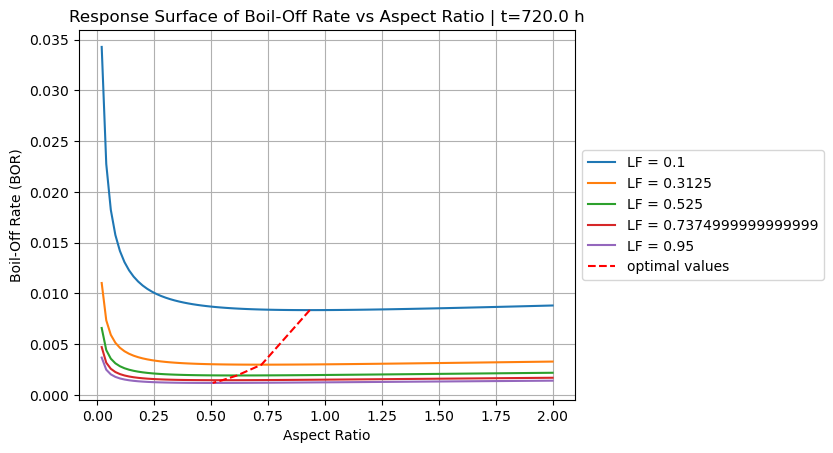

In [7]:
opti.plot_surface_response_liquid_filling(jnp.linspace(0.02, 2, 100), jnp.linspace(0.1, 0.95, 5),720*3600)

In [8]:
opti.plot_thermal_surface_response(jnp.linspace(0.1, 0.95, 100), 2*3600)
opti.plot_thermal_surface_response(jnp.linspace(0.1, 0.95, 100), 48*3600)
opti.plot_thermal_surface_response(jnp.linspace(0.1, 0.95, 100), 720*3600)

AttributeError: 'Opti_jax' object has no attribute 'plot_thermal_surface_response'

optimal Thermal Aspect Ratio: [0.70113295 0.68166803 0.67258622 0.66830922 0.66680772]
optimal BOR: [0.00906337 0.00323699 0.00208415 0.00157672 0.00128565]


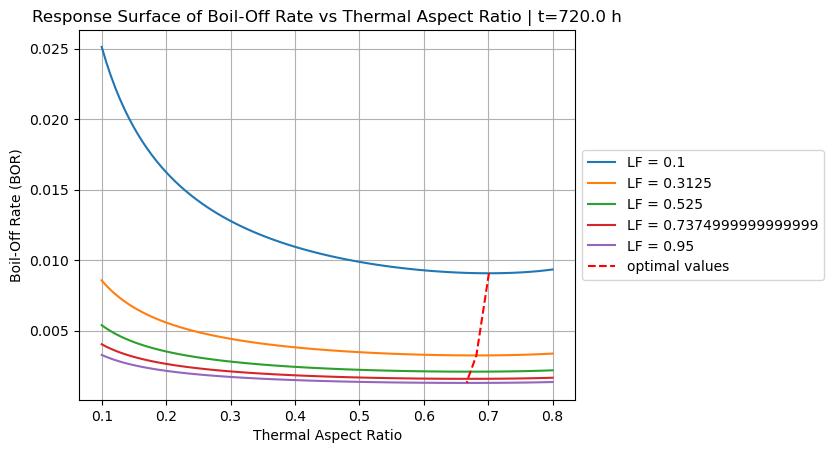

In [ ]:
opti.plot_surface_response_thermal_liquid_filling(jnp.linspace(0.1, 0.8, 100), jnp.linspace(0.1, 0.95, 5),720*3600)

In [8]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=2*3600, coarse_samples=100, fine_samples=1000,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.200000, BOR: 9.198967e-04
Phase 2: Fine grid search with 1000 samples...
Refined optimal aspect ratio: 0.200000
Minimum BOR: 9.198967e-04
Tiempo de ejecución: 2.78 segundos


In [9]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=48*3600, coarse_samples=100, fine_samples=1000,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.200000, BOR: 9.195755e-04
Phase 2: Fine grid search with 1000 samples...
Refined optimal aspect ratio: 0.200000
Minimum BOR: 9.195755e-04
Tiempo de ejecución: 11.35 segundos


In [10]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=720*3600, coarse_samples=100, fine_samples=100,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.200000, BOR: 9.195303e-04
Phase 2: Fine grid search with 100 samples...
Refined optimal aspect ratio: 0.200000
Minimum BOR: 9.195303e-04
Tiempo de ejecución: 17.38 segundos


In [11]:
# optimal_aspect_ratio = opti.optimize(max_iter = 500, t_final = 2 * 3600, lr = 1e-2, x0 = 0, lr_2 = 1e-3, iter_decay_lr=75)
# opti.plot_loss_history()

In [12]:
opti.optimal_aspect_ratio

Array(0.2, dtype=float64)

Se establecen los siguientes casos para ver su variabilidad

flux base:
$$
q_b = \lambda * U_L(T_{air}-T_L)
$$
$\lambda$ constante para variar el flux $q_b$ base
$$
\frac{q_b}{q_w} = {0.1, 1, 10}
$$


In [2]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K

V_tank = 165000 # Tank volume / m^3

# internal diameter / m
d_i = 76.4
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.038 # 0.08 # W/m2/K
U_V = 0.038 # 0.08 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.9

# Specify tank operating pressure
P = 100000 # Pa

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)

# Initialize cryogen
cryogen = Cryogen(name = "methane")
cryogen.set_coolprops(P)

# Set cryogen
large_tank.cryogen = cryogen

# Set fixed bottom heat ingress
phi = 0.1 # fraction of heat flux between bottom and walls
q_b_fixed = phi*U_L*(T_air - cryogen.T_sat) # W/m2

# initialize heat transfer properties
large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = q_b_fixed, Q_roof = 0, eta_w = 0.70)

Comparacion de valores de q_b

In [3]:
# comparison of heat flux

print("q_b used: ", large_tank.q_b_fixed, " q_b free: ", U_L*(T_air - cryogen.T_sat))
print("Q_b used: ", large_tank.Q_b, " Q_b free: ", U_L*(T_air - cryogen.T_sat)*(np.pi*((d_i**2)/4)))
print("Q_l used: ", large_tank.Q_L_in, " q_l :", large_tank.Q_L_in/large_tank.A_L)

print("ratio Q_b/Q_l: ", large_tank.Q_b/large_tank.Q_L_in, " ratio q_b/q_l: ", (large_tank.Q_b/large_tank.A_T)/(large_tank.Q_L_in/large_tank.A_L)   )
print("ratio q_b/q_l lambda = 0.1: ", 0.1*(large_tank.Q_b/large_tank.A_T)/(large_tank.Q_L_in/large_tank.A_L)   )


q_b used:  0.7092410212587223  q_b free:  7.092410212587223
Q_b used:  3251.400326485622  Q_b free:  32514.003264856216
Q_l used:  56245.41229846004  q_l : 7.0924102125872235
ratio Q_b/Q_l:  0.057807387191553095  ratio q_b/q_l:  0.1
ratio q_b/q_l lambda = 0.1:  0.01


In [4]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 720 hours
evap_time = 3600 * 720

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6


In [5]:
opti = Opti_jax(large_tank)

Optimal aspect ratio for q_b_fixed =  0.7092410212587223


/home/sotoj/Ipre/lib/python3.12/site-packages/cryoevap/optimize/opti_jax.py:517: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


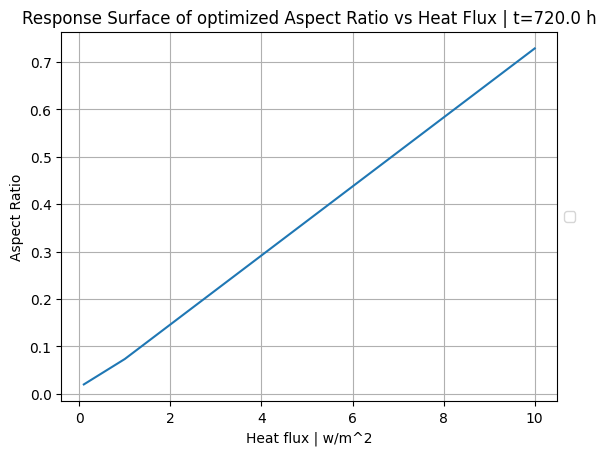

Optimal aspect ratio for q_b_fixed =  0.7092410212587223


In [ ]:
print("q_b_fixed = ", large_tank.q_b_fixed)
opti.plot_surface_response_bottom_heat(jnp.array([0.1,1,10]), 720*3600)
print("q_b_fixed = ", large_tank.q_b_fixed)

+-------------------------------------------------------------+
| Optimal Thermal aspect ratio:    0.6682637352501472               |
| Optimal Geometric aspect ratio:  0.05191211413433636               |
| Minimal BOR:                     0.00011652092826964407               |
+-------------------------------------------------------------+


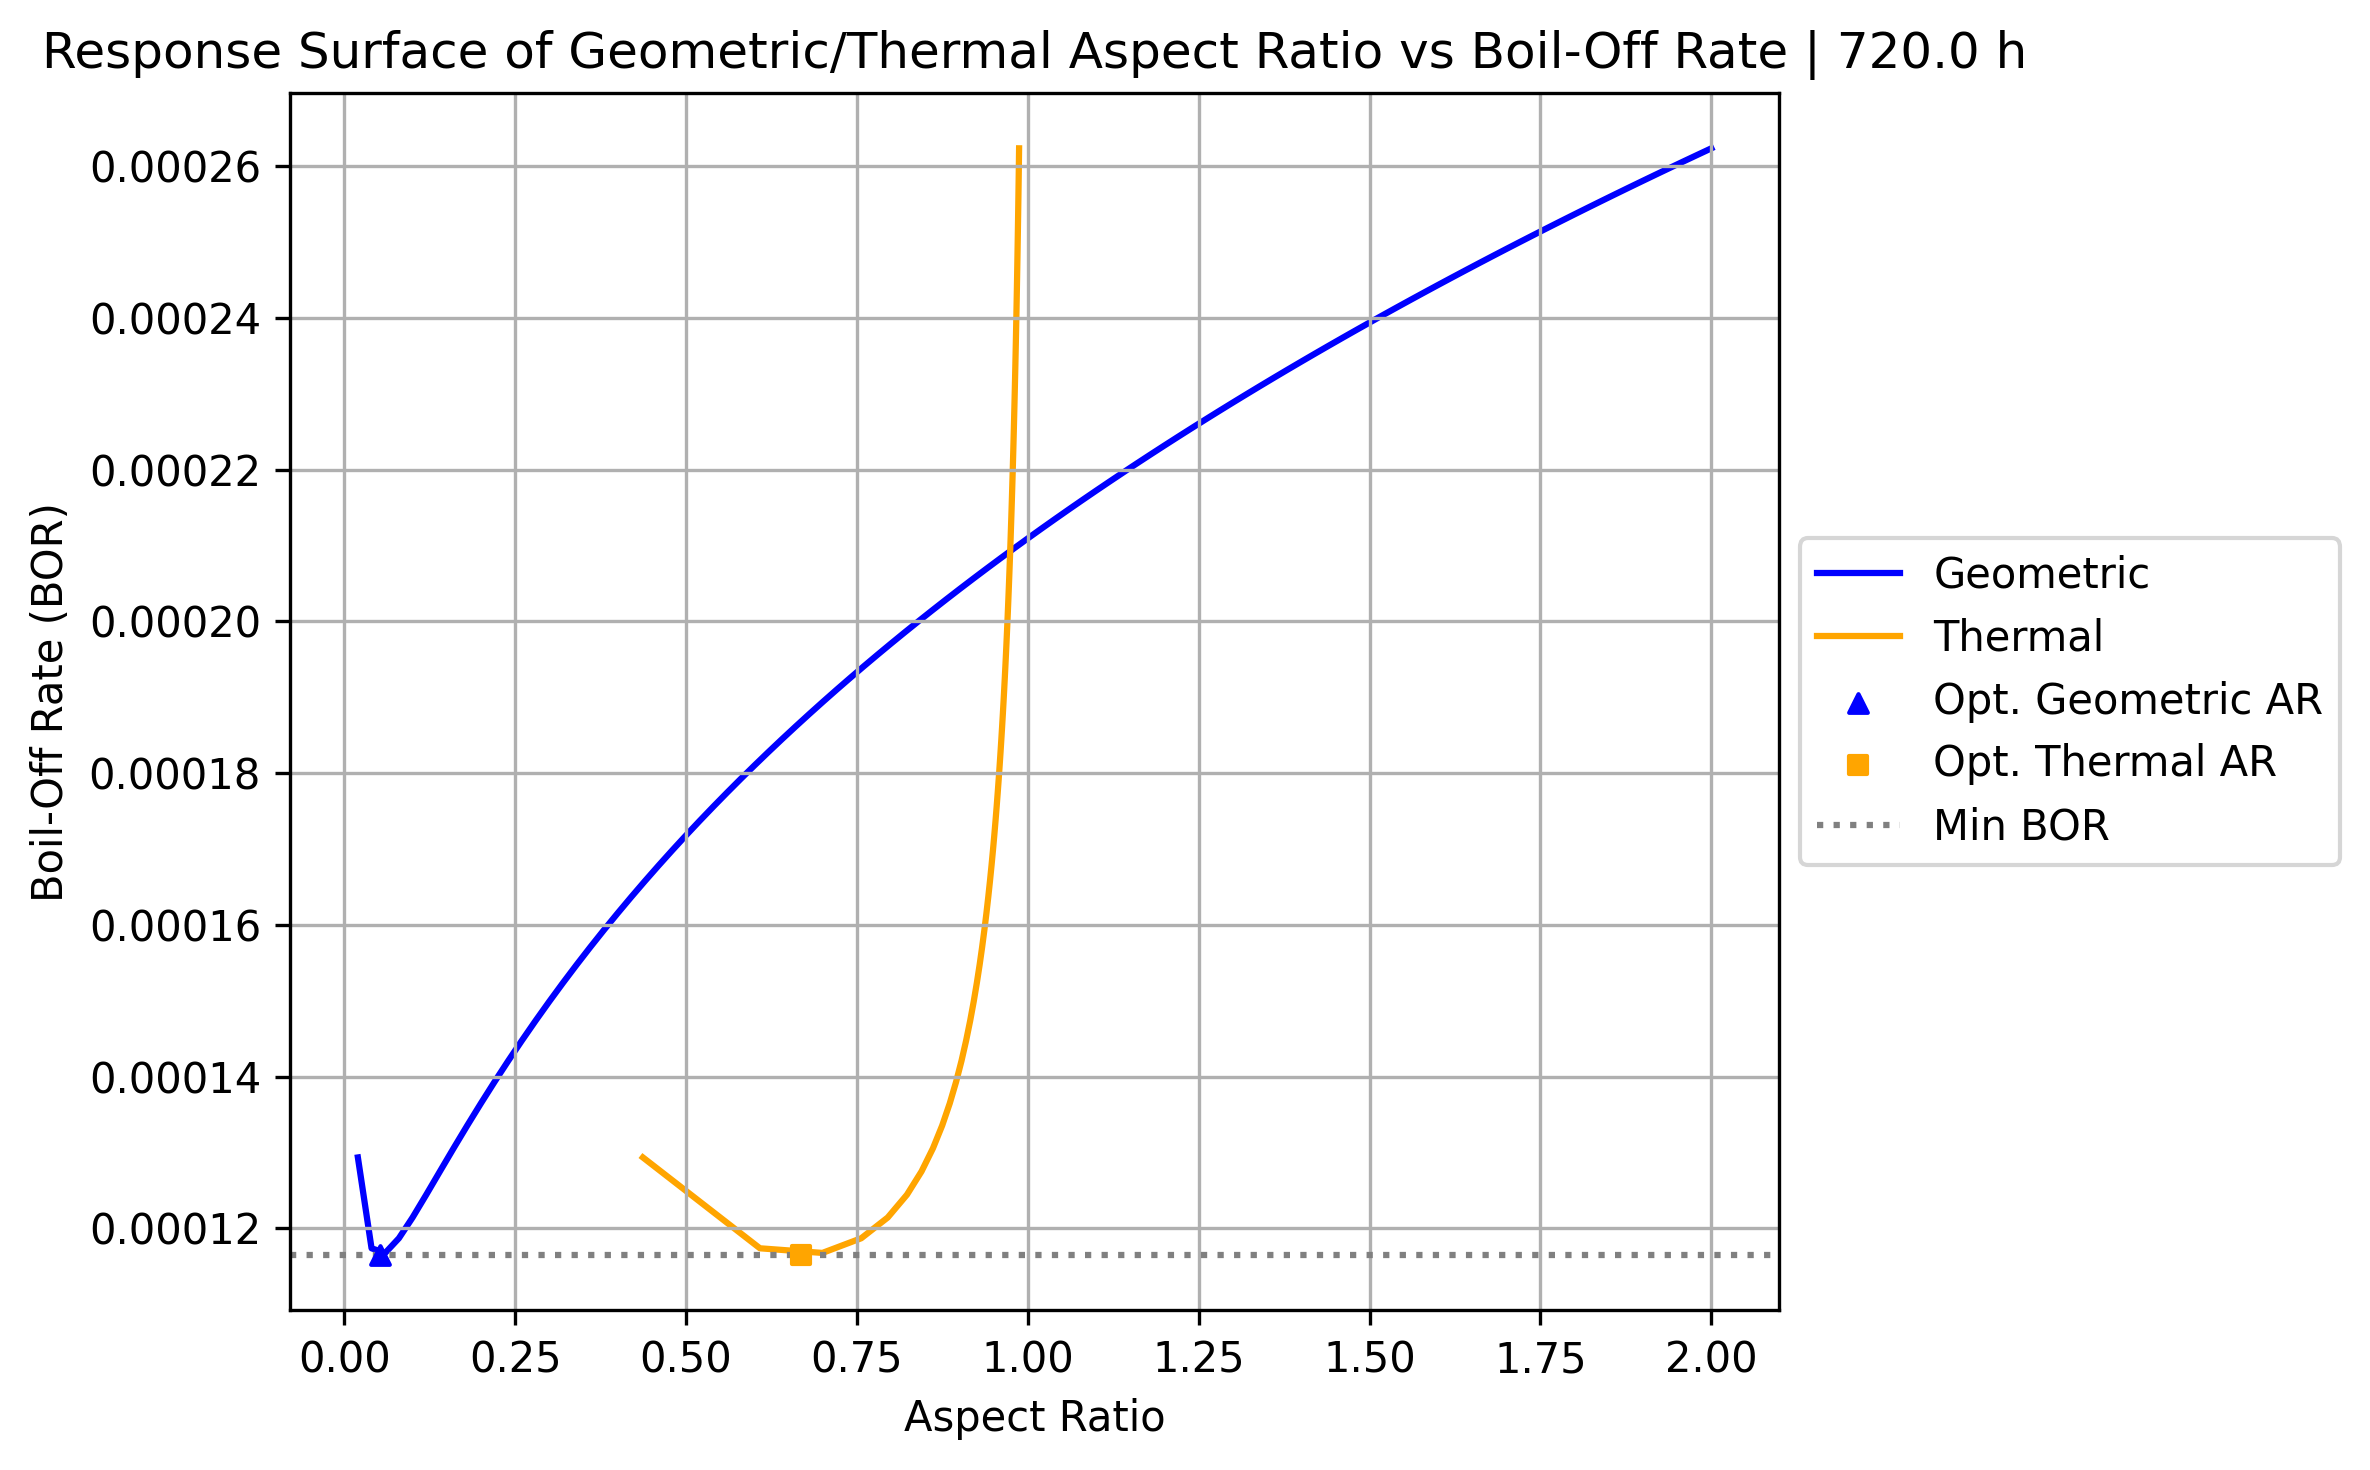

In [7]:
opti.plot_aspect_ratio_surface_response(jnp.linspace(0.02, 2, 100), 720*3600)

probar cambiar directamente q_b_fixed sin tener que inicializar

In [11]:
# Set fixed bottom heat ingress
phi = 10 # fraction of heat flux between bottom and walls
q_b_fixed = phi*U_L*(T_air - cryogen.T_sat) # W/m2

large_tank.q_b_fixed = q_b_fixed # W/m2
opti.params["q_b_fixed"] = large_tank.q_b_fixed
print("q_b_fixed = ", large_tank.q_b_fixed)
print("q_b_fixed = ", opti.q_b_fun((opti.params)))

q_b_fixed =  70.92410212587224
q_b_fixed =  70.92410212587224


+-------------------------------------------------------------+
| Optimal Thermal aspect ratio:    0.6669603754165               |
| Optimal Geometric aspect ratio:  5.158459368459369               |
| Minimal BOR:                     0.0005329979826959152               |
+-------------------------------------------------------------+


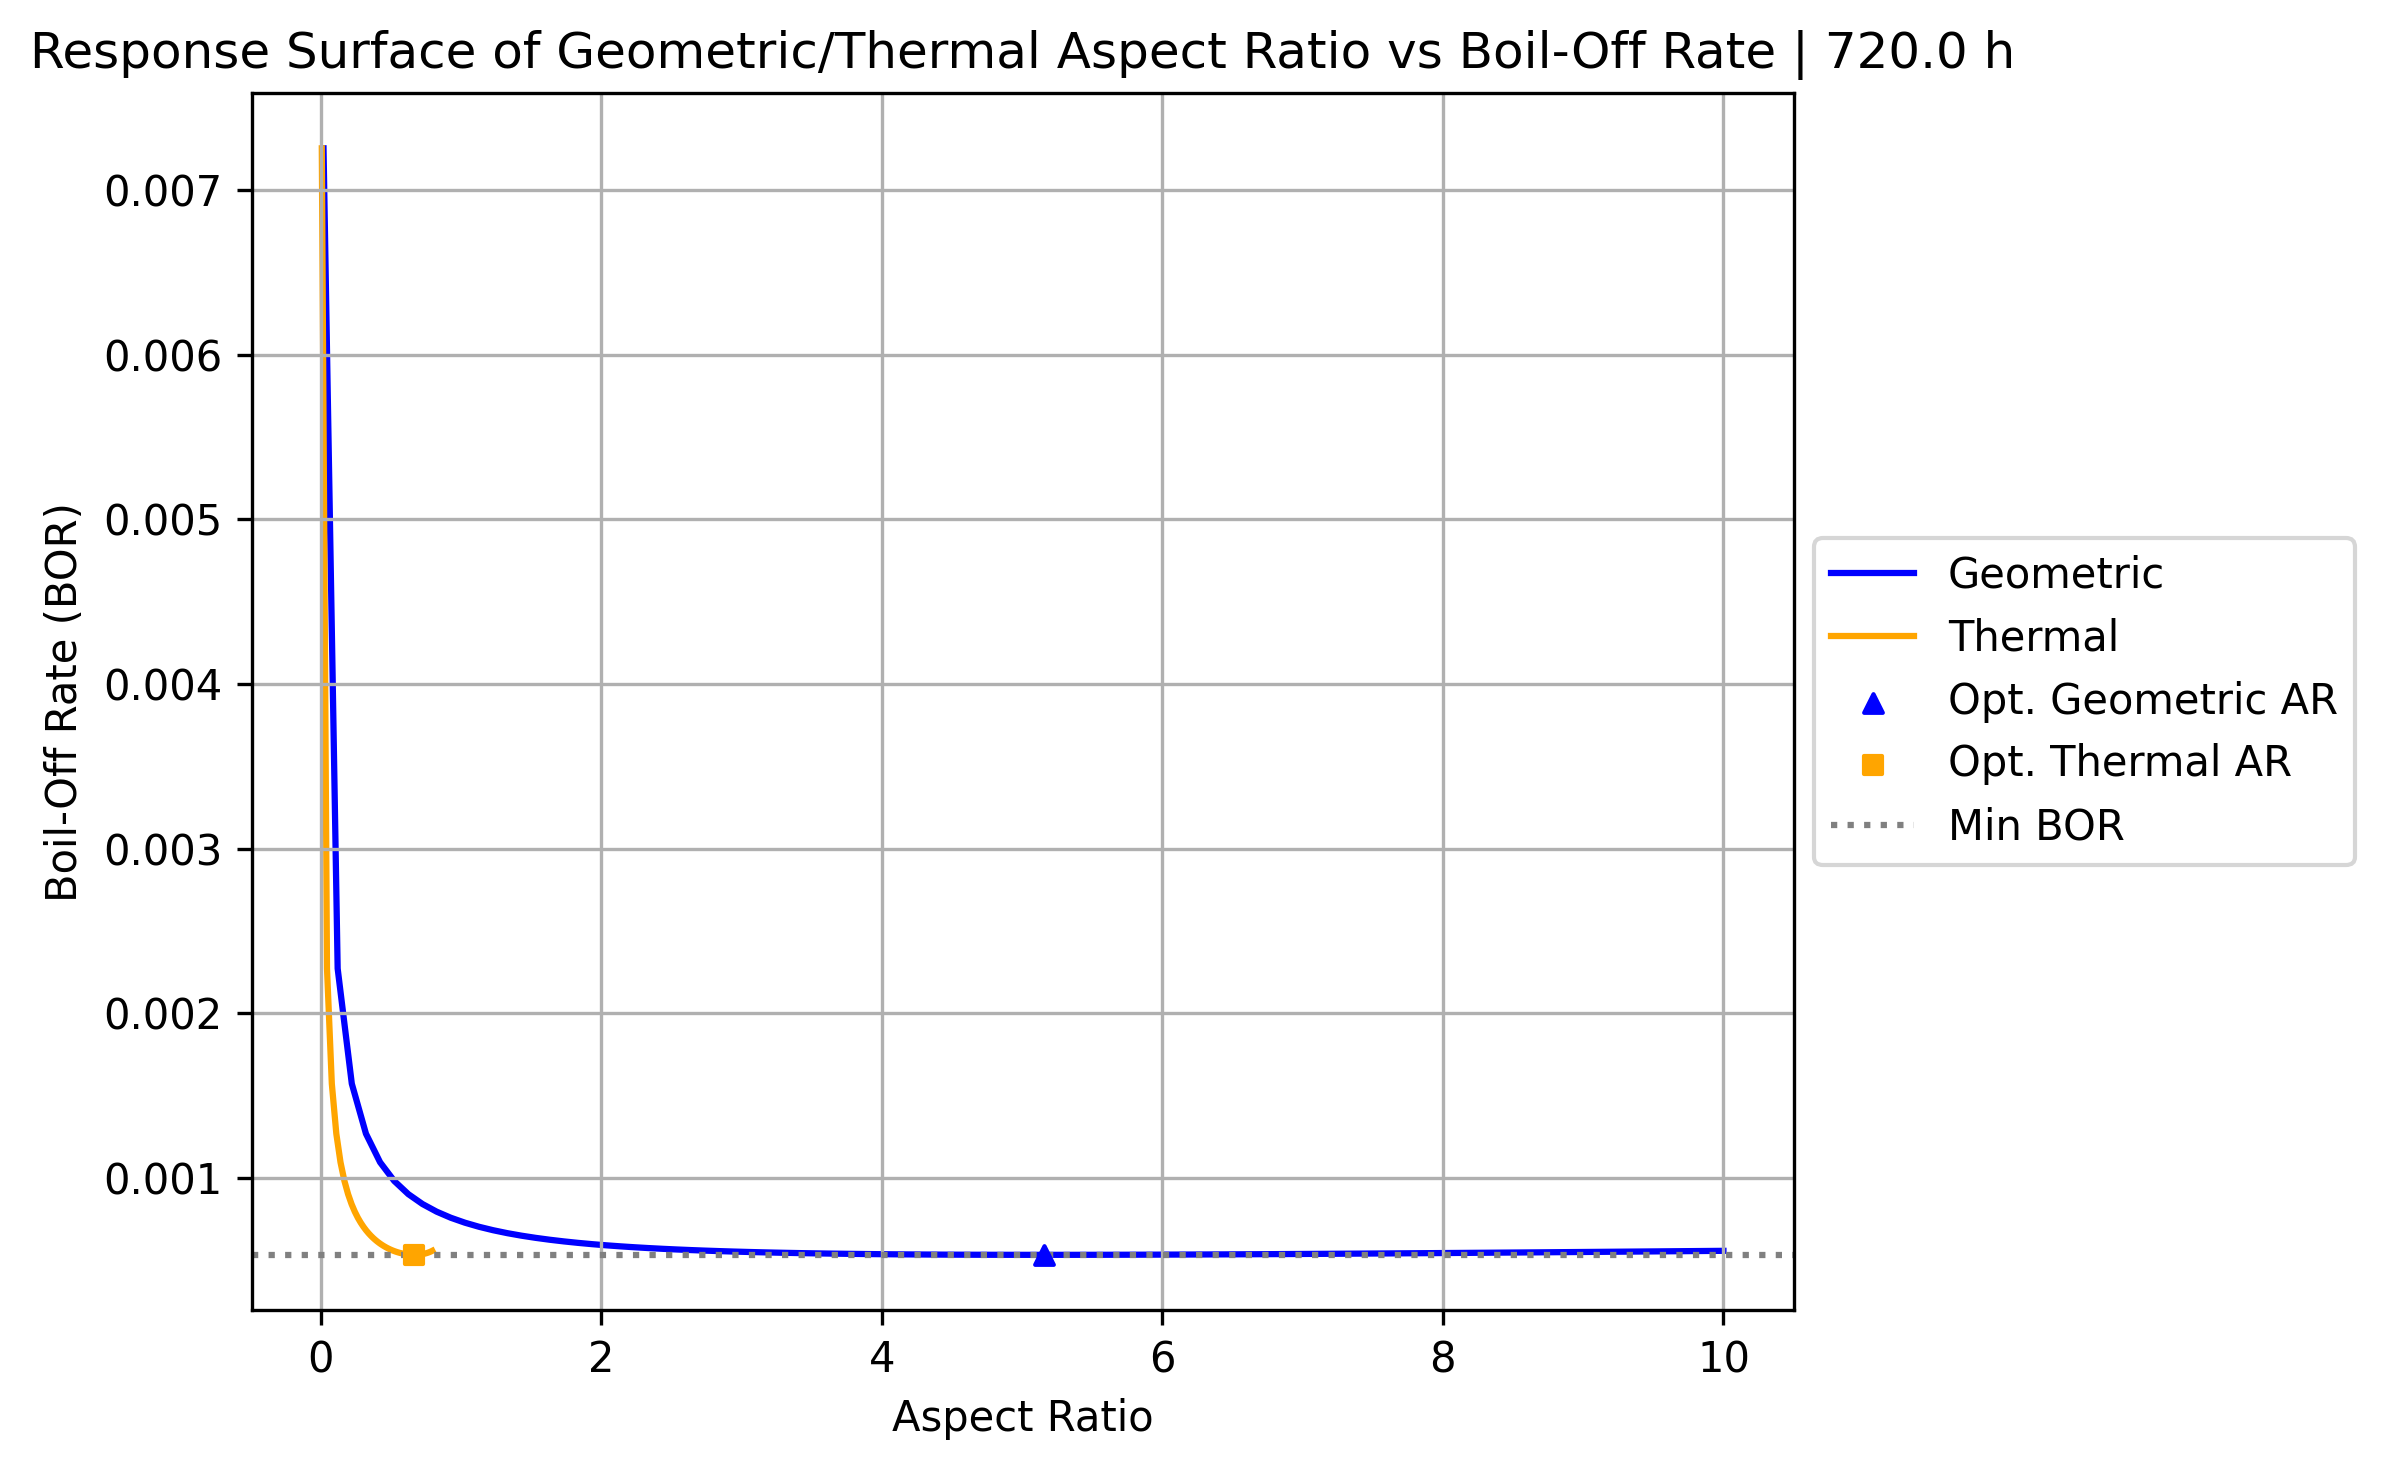

In [8]:
opti.plot_aspect_ratio_surface_response(jnp.linspace(0.02, 10, 100), 720*3600)

#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.